# 09 — Build masked clean-split dataset (radius-scaling, factor 0.9)

Applies a clean radius-scaled circular mask (keeps inner 90% of the retinal circle, removing the outer boundary ring) to every image, saving them by class so the five models retrain on masked data using the SAME deduplicated split indices. Radius-scaling avoids the star artefacts that morphological erosion produced.

**Attach:** dataset, build_clean_split. Run All (CPU). Then commit so the masked dataset attaches to the training notebooks.

In [1]:
import os, cv2, numpy as np, torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import datasets
DATA_ROOT='/kaggle/input/datasets/shajinrp/diabetic-retinopathy/Dataset'
OUT='/kaggle/working/masked'
os.makedirs(OUT, exist_ok=True)
RADIUS_FACTOR=0.9
print('radius factor:', RADIUS_FACTOR)

radius factor: 0.9


## Radius-scaling mask function

In [2]:
import cv2, numpy as np
from PIL import Image

def apply_circular_mask_scaled(pil_image, radius_factor=0.9):
    """
    Detect the retinal circle, then keep only the inner `radius_factor`
    of that circle. Radius-scaling shrinks the kept region cleanly, with
    no morphological star artefacts. factor=0.9 removes the outer 10%
    (the boundary ring) while keeping the diagnostic retinal interior.
    """
    img_np = np.array(pil_image)
    grey   = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(grey, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return pil_image
    largest = max(contours, key=cv2.contourArea)
    (cx, cy), radius = cv2.minEnclosingCircle(largest)
    cx, cy = int(cx), int(cy)
    radius = int(radius * radius_factor)
    mask = np.zeros(grey.shape, dtype=np.uint8)
    cv2.circle(mask, (cx, cy), radius, 255, thickness=-1)
    mask_3ch = np.stack([mask]*3, axis=-1)
    masked = np.where(mask_3ch == 255, img_np, 0)
    return Image.fromarray(masked.astype(np.uint8))


## Apply mask to every image, save organised by class

In [3]:
full = datasets.ImageFolder(DATA_ROOT)
class_names = full.classes
for c in class_names: os.makedirs(f'{OUT}/{c}', exist_ok=True)
print('Classes:', class_names, '| total:', len(full.samples))

fail=0
for idx,(path,label) in enumerate(full.samples):
    try:
        pil = Image.open(path).convert('RGB')
        masked = apply_circular_mask_scaled(pil, radius_factor=RADIUS_FACTOR)
        masked.save(f'{OUT}/{class_names[label]}/{os.path.basename(path)}')
    except Exception as e:
        fail+=1
        if fail<=5: print('fail:', path, e)
    if idx % 500 == 0: print(f'  {idx}/{len(full.samples)}')
print(f'Done. {len(full.samples)-fail} saved, {fail} failed.')
masked_count = sum(len(os.listdir(f'{OUT}/{c}')) for c in class_names)
print('Masked on disk:', masked_count, '(should equal', len(full.samples), ')')

Classes: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe'] | total: 3554
  0/3554
  500/3554
  1000/3554
  1500/3554
  2000/3554
  2500/3554
  3000/3554
  3500/3554
Done. 3554 saved, 0 failed.
Masked on disk: 3554 (should equal 3554 )


## Verification grid — confirm masks before training

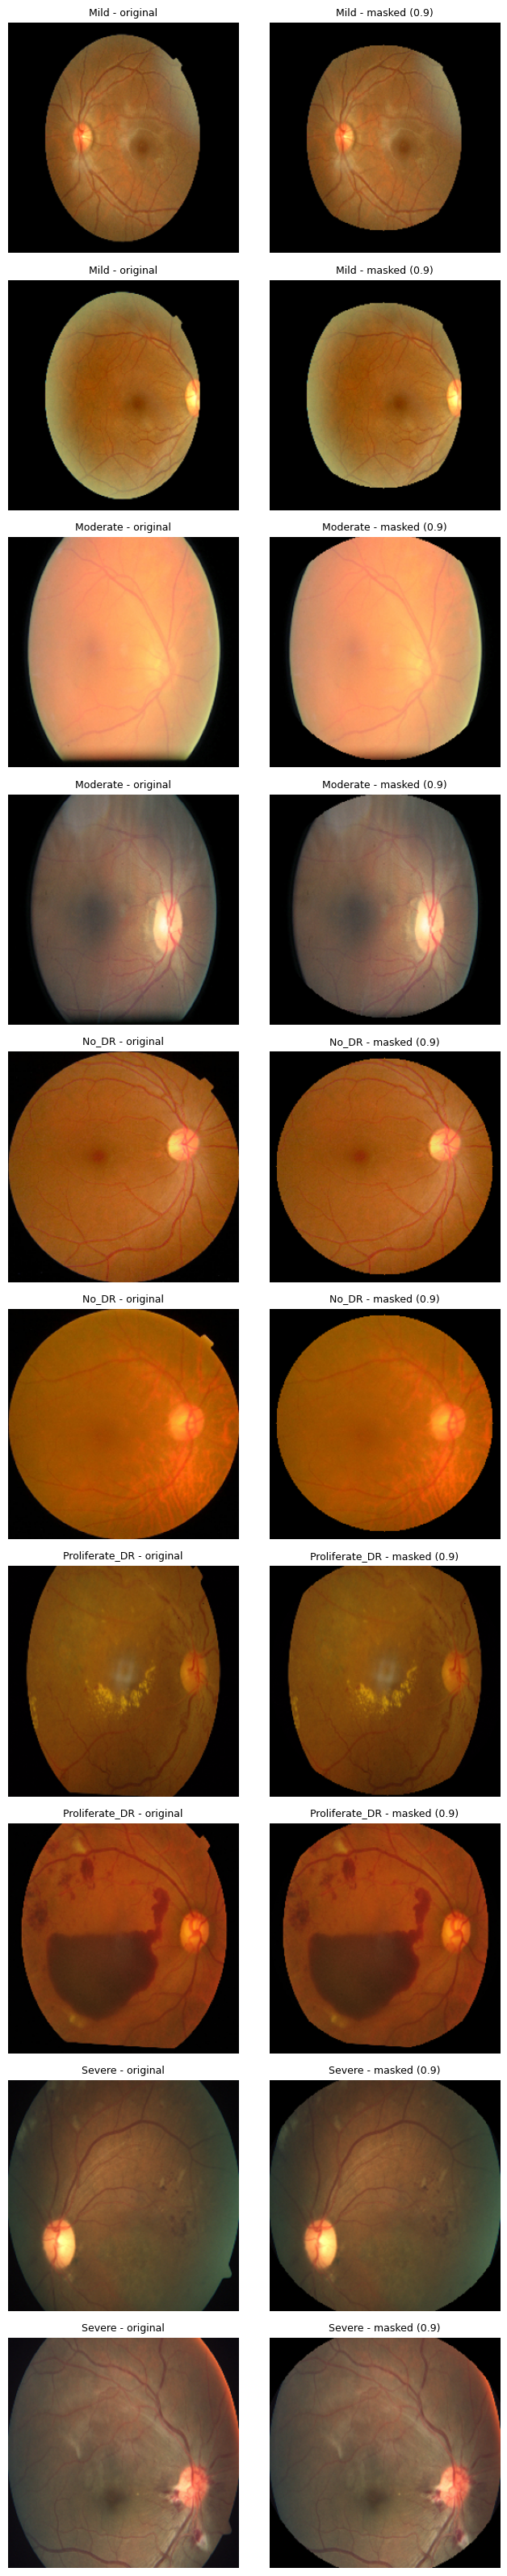

Inspect, then commit if correct.


In [4]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(len(class_names)*2, 2, figsize=(7, 3.2*len(class_names)*2))
row=0
for c in class_names:
    files = os.listdir(f'{DATA_ROOT}/{c}')
    for fn in rng.choice(files, size=2, replace=False):
        orig = Image.open(f'{DATA_ROOT}/{c}/{fn}').convert('RGB').resize((256,256))
        mask = Image.open(f'{OUT}/{c}/{fn}').convert('RGB').resize((256,256))
        axes[row,0].imshow(orig); axes[row,0].set_title(f'{c} - original',fontsize=9); axes[row,0].axis('off')
        axes[row,1].imshow(mask); axes[row,1].set_title(f'{c} - masked (0.9)',fontsize=9); axes[row,1].axis('off')
        row+=1
plt.tight_layout(); plt.savefig('/kaggle/working/mask_verification.png',dpi=120,bbox_inches='tight')
plt.show()
print('Inspect, then commit if correct.')